In [1]:
import catalogue_analysis as ca
import redshift_weights as rw
import numpy as np
from astropy.table import join,Table,Column,vstack,setdiff
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
#Target Catalogue
tpath='/global/cfs/cdirs/desi/survey/catalogs/main/LSS/BGS_BRIGHTtargetsDR9v1.1.1.fits'  
target=Table.read(tpath)
# LSS Catalogue
fpath='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/nonKP/BGS_BRIGHT_clustering.dat.fits' #clustering catalogue
lss=ca.Y3load_catalogues(fpath)
#"Full"  catalogue from which we extract the observed and zgood subsets
fullfile='/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/test/BGS_BRIGHT_full_HPmapcut.dat.fits' #full observed catalogue used for redshift weights 
zgood,observed= ca.load_full_catalogue_subsets(fullfile)
# Read the Siena Galaxy catalogue and compare redshifts for matched objects
SGA='/pscratch/sd/s/smcole/SGA-2020.fits'
sga=Table.read(SGA)
# Augmented catalogue with rest frame magnitudes, zmin, zmax etc
Augmented="sdata/BGS_Y3_Dec2025All.fits"
aug=Table.read(Augmented)

info= True
if (info):
    print('Statistics of the observed catalogue:')
    observed.info('stats')
    print('Statistics of the zgood catalogue:')
    zgood.info('stats')
    print('Statistics of the LSS catalogue:')
    lss.info('stats')    
    print('Statistics of the target catalogue')
    target.info('stats')
    print('Statistics of the SGA catalogue')
    sga.info('stats')
    print('Statistics of the Augmeted catalogue')
    aug.info('stats')




Size of Full catalogue 10623399
Faintest Fibre mag: 25.411306 NB BGS was limited to r_fib=23 in an earlier version of the photometry
number of objects in the observed subset 7980009
number of objects in the good redshift subset 7887861
Faintest Observed Fibre mag: 25.411306
Statistics of the observed catalogue:
<Table length=7980009>
           name                mean         std         min          max      n_bad 
-------------------------- ------------ ----------- ------------ ----------- -------
                  TARGETID  3.96297e+16 2.48551e+12  3.96273e+16 3.96374e+16       0
                MWS_TARGET     0.164555     33.0836            0       10240       0
               SUBPRIORITY     0.545707    0.285051  6.22789e-07           1       0
             PRIORITY_INIT         2100           0         2100        2100       0
              TARGET_STATE           --          --           --          --       0
                 TIMESTAMP           --          --           --     

Fraction of SGA galaxies with redshifts: 0.690042229289401


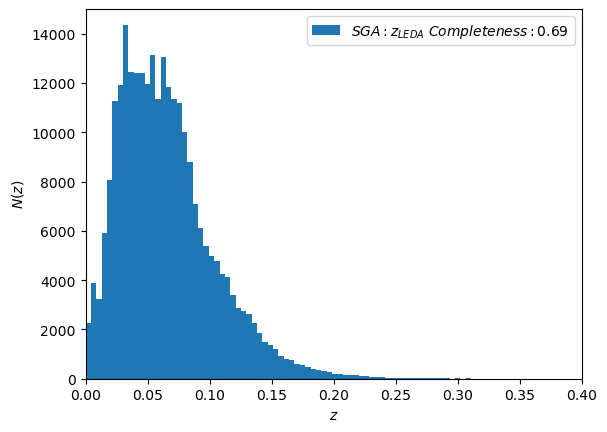

In [3]:
# Fraction of SGA galaxies that have redshifts
mask = (sga['Z_LEDA']>0)
zcompl_sga=mask.sum()/len(mask)
print('Fraction of SGA galaxies with redshifts:',zcompl_sga)
label=f"{zcompl_sga:.2f}"
# SGA redshift histogram
plt.xlabel('$z$')
plt.ylabel('$N(z)$')
plt.hist(sga['Z_LEDA'][mask],bins=1000,label='$SGA: z_{LEDA}\ Completeness:$'+label)
plt.xlim([0,0.4])
plt.ylim([0.0,15000])
plt.legend()
plt.show()

Redshifts found for the five brightest galaxies identified by Jake:
    Z_LEDA   
-------------
  0.029807618
0.00019446785
  0.023974918
 0.0026041348
  0.008075252
Maximum separation of matches to BGS target catalogue s= 0d13m32.83728859s
Maximum separation of matches to BGS target catalogue s/D25= 0.01585667312507875


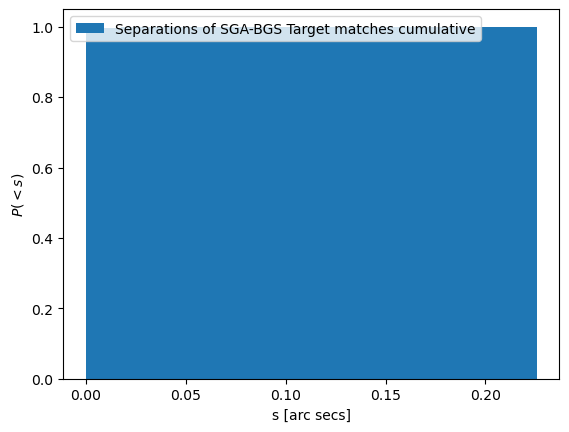

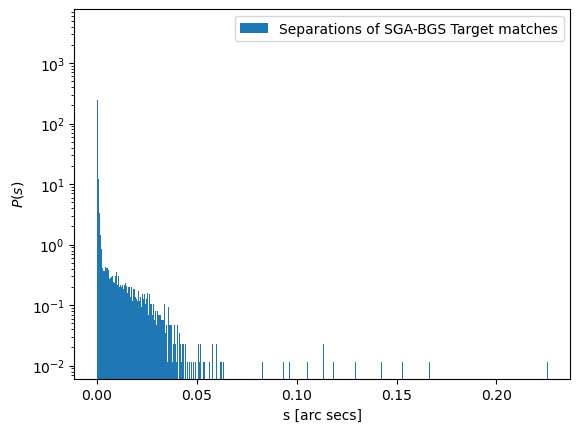

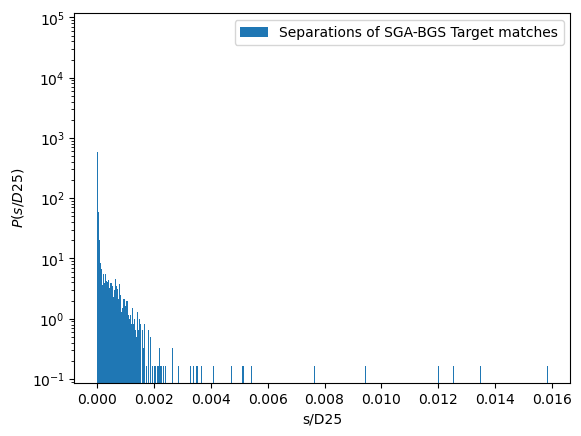

In [4]:
# Table of the 5 "brightest" galaxies identified by Jake Howard
brights=Table()
brights['RA']      =([221.7600641109203 ,189.43844431224474, 198.37224607038027, 182.84482212020578, 225.3068747759829   ])
brights['DEC']     =([-2.3854087156867214,  7.105441377506101, 45.33573757093353, 50.26958790623495,  52.59580931947117  ])
brights['TARGETID']=([39627728051241346,   39627956712114667, 39633170693361035, 39633251983164574,  39633286472928387 ])

# Convert to SkyCoord
coords_brights = SkyCoord(ra=brights['RA']*u.deg,dec=brights['DEC']*u.deg)
coords_sga = SkyCoord(ra=sga['RA_LEDA']*u.deg, dec=sga['DEC_LEDA']*u.deg)
coords_target = SkyCoord(ra=target['RA']*u.deg, dec=target['DEC']*u.deg)

# Match each object in sga to the nearest in the target and lss table and each object in brights to the nearest in SGA
idx_tar, sep2d_tar, _ = coords_sga.match_to_catalog_sky(coords_target)
idx_sga, sep2d_sga, _ = coords_brights.match_to_catalog_sky(coords_sga)

# SGA redshifts of the 5 brightest
print('Redshifts found for the five brightest galaxies identified by Jake:')
print(sga['Z_LEDA'][idx_sga])

#
print('Maximum separation of matches to BGS target catalogue s=',max(sep2d_tar))
print('Maximum separation of matches to BGS target catalogue s/D25=',max((sep2d_tar.value/(60.0*sga['D25_LEDA'])) ) )

#Plot histogram of separation of matches
plt.xlabel('s [arc secs]')
plt.ylabel('$P(<s)$')
plt.hist(sep2d_tar,bins=1000,density=True,cumulative=True,label='Separations of SGA-BGS Target matches cumulative')
#plt.xlim([0,55.0])
#plt.ylim([0.0,15000])
plt.legend()
plt.show()


plt.xlabel('s [arc secs]')
plt.ylabel('$P(s)$')
plt.hist(sep2d_tar,bins=1000,density=True,cumulative=False,label='Separations of SGA-BGS Target matches')
#plt.xlim([0,813.0])
plt.yscale('log')
#plt.ylim([0.0,0.1])
plt.legend()
plt.show()



plt.xlabel('s/D25')
plt.ylabel('$P(s/D25)$')
plt.hist(sep2d_tar/(60.0*sga['D25_LEDA']),bins=1000,density=True,cumulative=False,label='Separations of SGA-BGS Target matches')
#plt.xlim([0,55.0])
plt.yscale('log')
#plt.ylim([0.0,0.1])
plt.legend()
plt.show()


Fraction of SGA galaxies for which DESI match found within  10.0 arcsec : 0.9938663260518221


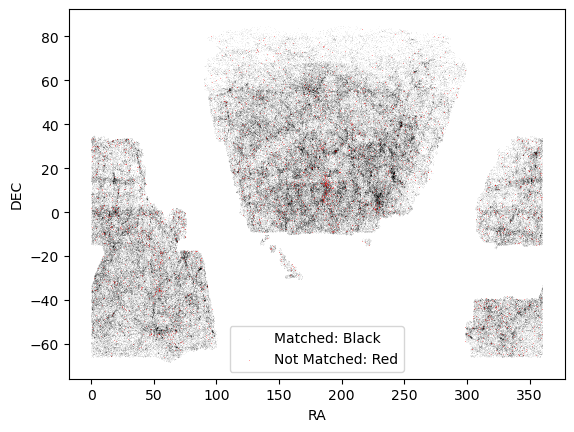

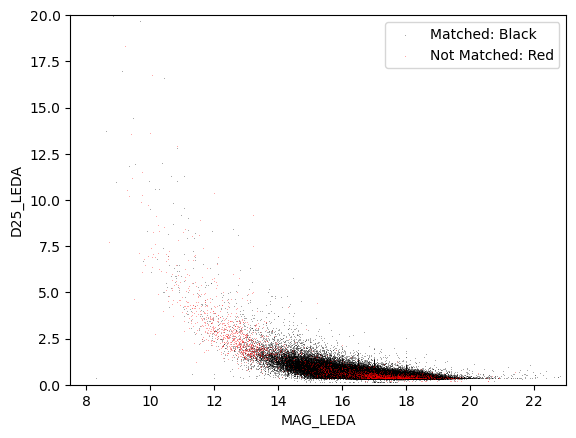

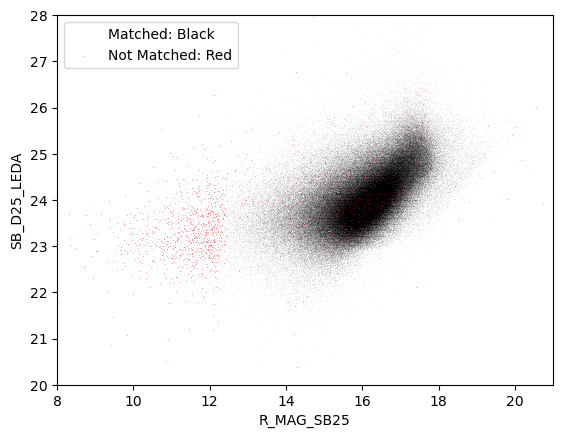

In [5]:
maxsep= 10.0* u.arcsec
mask= (sep2d_tar<maxsep)
print('Fraction of SGA galaxies for which DESI match found within ',maxsep,':',mask.sum()/len(mask))

# Plot RA and dec of matched and unmatched SGA galaxies
plt.scatter(sga['RA_LEDA'][mask],sga['DEC_LEDA'][mask],color='black',s=0.5,marker='.', alpha=0.1, linewidths=0,label='Matched: Black') 
plt.scatter(sga['RA_LEDA'][~mask],sga['DEC_LEDA'][~mask],color='red',s=0.5,marker='.', alpha=1.0, linewidths=0,label='Not Matched: Red') 
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend()
plt.show()


# Plot Magnitude and Diameter of matched and unmatched SGA galaxies
# MAG_LEDA Approximate brightness (Note: this magnitude estimate is heterogeneous in both bandpass and aperture but for most galaxies it is measured in the B-band within D25_LEDA ; use with care.)
# D25_LEDA Approximate major-axis diameter at the 25 mag arcsec−2 (optical) surface brightness isophote, taken from the reference indicated in REF (but see also the BYHAND column).
plt.scatter(sga['MAG_LEDA'][mask],sga['D25_LEDA'][mask],color='black',s=0.5,marker='.', alpha=1.0, linewidths=0,label='Matched: Black') 
plt.scatter(sga['MAG_LEDA'][~mask],sga['D25_LEDA'][~mask],color='red',s=0.5,marker='.', alpha=1.0, linewidths=0,label='Not Matched: Red') 
plt.xlabel('MAG_LEDA')
plt.ylabel('D25_LEDA')
plt.xlim([7.5,23.0])
plt.ylim([0.0,20.0])
plt.legend()
plt.show()


# Plot Magnitude and Diameter of matched and unmatched SGA galaxies
#R_MAG_SB25: Cumulative brightness measured within SMA_SB=25
#SB_D25_LEDA: Mean surface brightness within D25_LEDA based on the brightness in MAG_LEDA.
plt.scatter(sga['R_MAG_SB25'][mask],sga['SB_D25_LEDA'][mask],color='black',s=0.5,marker='.', alpha=0.1, linewidths=0,label='Matched: Black') 
plt.scatter(sga['R_MAG_SB25'][~mask],sga['SB_D25_LEDA'][~mask],color='red',s=0.5,marker='.', alpha=1.0, linewidths=0,label='Not Matched: Red') 
plt.xlabel('R_MAG_SB25')
plt.ylabel('SB_D25_LEDA')
plt.xlim([8.0,21.0])
plt.ylim([20,28.0])
plt.legend()
plt.show()


In [6]:

def link_indices_by_key(table1, table2, key='TARGETID', assume_unique=True):
    """
    Create an index mapping from rows in table1 to rows in table2 based on a key column.

    Parameters
    ----------
    table1 : astropy.table.Table
        First table. We will create an index mapping for each of its rows.
    table2 : astropy.table.Table
        Second table, where we look up matches by `key`.
    key : str, optional
        Column name to match on. Default is 'TARGETID'.
    assume_unique : bool, optional
        If True (default), assumes `table2[key]` has unique values. This is faster and
        returns a single index per row in table1 (or -1 if no match).
        If False, supports duplicates in `table2[key]`. Returns a Python list of indices
        per row in table1 (empty list if no match).

    Returns
    -------
    mapped_indices : np.ndarray or list
        If assume_unique=True:
            A 1D NumPy array of length len(table1) with indices into table2,
            or -1 if no match for that row.
        If assume_unique=False:
            A list of length len(table1), where each element is a list of indices
            into table2 that match the key (possibly empty).
    match_mask : np.ndarray (bool)
        Boolean array of length len(table1) indicating whether there is (at least one) match.
        For assume_unique=False, True means the corresponding list is non-empty.

    Notes
    -----
    - This function works entirely in a vectorized manner for the unique-ID case using
      argsort + searchsorted (O(n log n)).
    - For non-unique IDs in table2, it builds ranges for duplicate blocks in the sorted
      array, still efficient compared to naive per-row searches.

    Examples
    --------
    >>> from astropy.table import Table
    >>> t1 = Table({'TARGETID': [10, 20, 30, 40]})
    >>> t2 = Table({'TARGETID': [20, 40, 50]})
    >>> idx, mask = link_indices_by_key(t1, t2, key='TARGETID', assume_unique=True)
    >>> idx
    array([-1,  0, -1,  1])
    >>> mask
    array([False,  True, False,  True])

    # Handling duplicates in table2:
    >>> t2 = Table({'TARGETID': [20, 20, 40, 40, 50]})
    >>> idx_lists, mask = link_indices_by_key(t1, t2, key='TARGETID', assume_unique=False)
    >>> idx_lists
    [[ ], [0, 1], [ ], [2, 3]]
    >>> mask
    array([False,  True, False,  True])
    """
    # Extract key columns as plain numpy arrays (avoids Column-specific edge cases)
    ids1 = np.asarray(table1[key])
    ids2 = np.asarray(table2[key])

    # Sort table2's key to enable binary search
    sort_idx = np.argsort(ids2)
    sorted_ids2 = ids2[sort_idx]

    # For every id in table1, find insertion position in sorted ids2
    pos = np.searchsorted(sorted_ids2, ids1)

    # Build boolean mask of exact matches
    # Need to guard pos==len(sorted_ids2) to avoid index error
    in_bounds = pos < len(sorted_ids2)
    matches = np.zeros(len(ids1), dtype=bool)
    matches[in_bounds] = sorted_ids2[pos[in_bounds]] == ids1[in_bounds]

    if assume_unique:
        # Map to original indices in table2; non-matches get -1
        mapped_indices = np.full(len(ids1), -1, dtype=int)
        mapped_indices[matches] = sort_idx[pos[matches]]
        return mapped_indices, matches
    else:
        # Find full ranges for duplicates in table2 for each matched id
        # For a matched id at position p, duplicates span:
        # left = searchsorted(sorted_ids2, id, side='left')
        # right = searchsorted(sorted_ids2, id, side='right')
        left_pos = np.searchsorted(sorted_ids2, ids1[matches], side='left')
        right_pos = np.searchsorted(sorted_ids2, ids1[matches], side='right')

        # Prepare list of lists aligned to table1
        mapped_lists = [[] for _ in range(len(ids1))]
        # Fill only for matched rows
        for i_row, (l, r) in zip(np.nonzero(matches)[0], zip(left_pos, right_pos)):
            # Convert sorted positions back to original table2 indices
            mapped_lists[i_row] = list(sort_idx[l:r])

        return mapped_lists, matches


In [7]:
# For objects in the Target catalogue find their match by TARGETID with those in the LSS catalogue
# Unmatched objects have matched=false and indx_dat=-1

indx_lss,matched=link_indices_by_key(target, lss, key='TARGETID', assume_unique=True)

# For objects in the Target catalogue find their match by TARGETID with those in the Augmented catalogue
# Unmatched objects have matched_aug=false and indx_dat=-1

indx_aug,matched_aug=link_indices_by_key(target, aug, key='TARGETID', assume_unique=True)

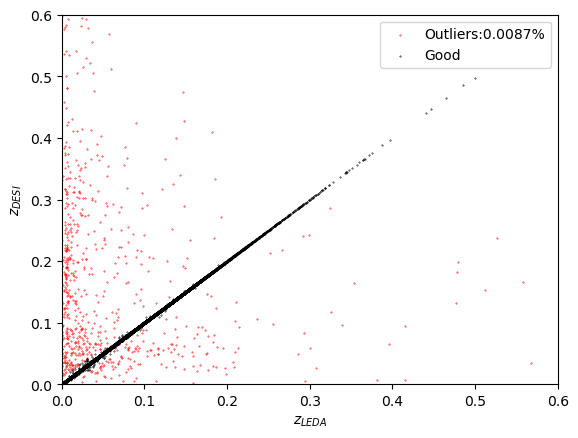

In [8]:
# For All the objects in SGA that have redshifts flag as bad those that disagree with the DESI redshift
bad = (np.abs(sga['Z_LEDA']-lss['Z'][indx_lss[idx_tar]]) >0.01) & (sga['Z_LEDA']>0) 
# For just those that match with the DESI full catalogue flag them as good or bad redh
matchedgood= matched[idx_tar] & ~bad
matchedbad= matched[idx_tar] & bad
#Fraction of Matched objects that have discrepant redshifts
fracbad= f"{100.0*matchedbad.sum()/matched.sum():.4f}"

plt.scatter(sga['Z_LEDA'][matchedbad],lss['Z'][indx_lss[idx_tar]][matchedbad],color='red',s=0.5,marker='.',linewidths=1,label='Outliers:'+fracbad+"%")
plt.scatter(sga['Z_LEDA'][matchedgood],lss['Z'][indx_lss[idx_tar]][matchedgood],color='black',s=0.5,marker='.',linewidths=1,label='Good')


plt.xlim([0,0.6])
plt.ylim([0.0,0.6])
plt.xlabel('$z_{LEDA}$')
plt.ylabel('$z_{DESI}$')
plt.legend()
plt.show()



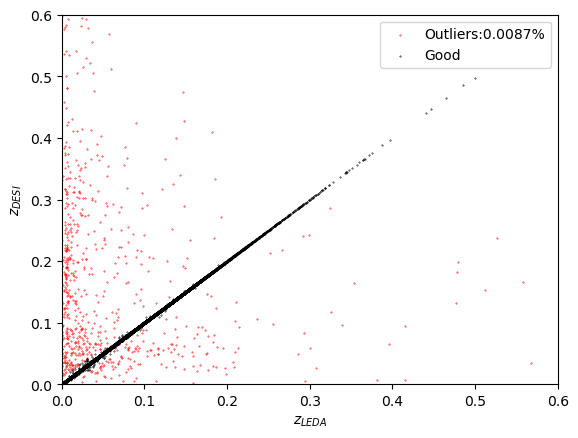

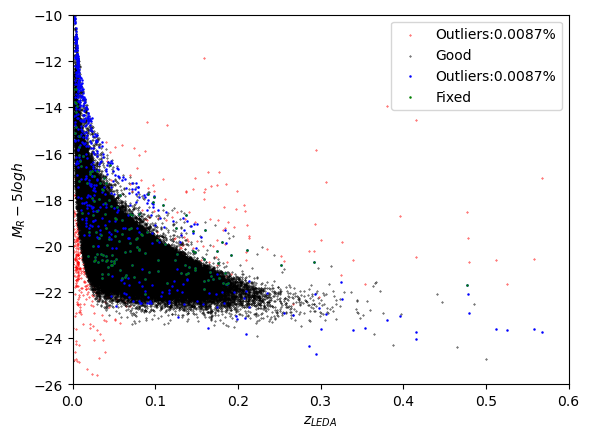

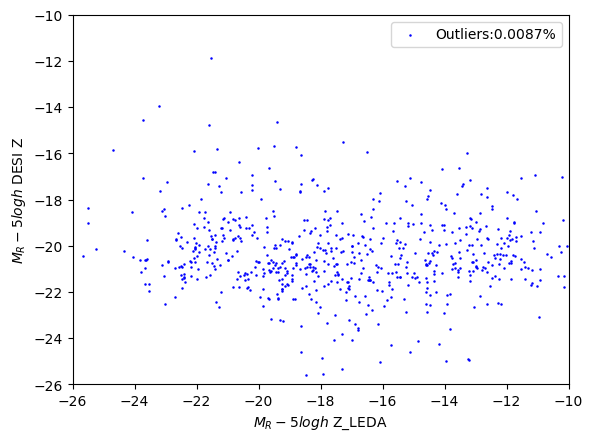

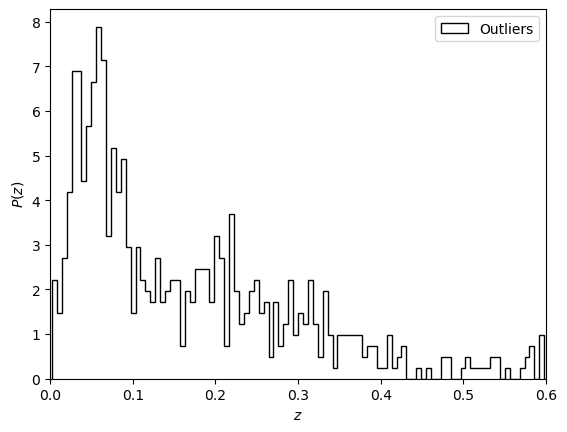

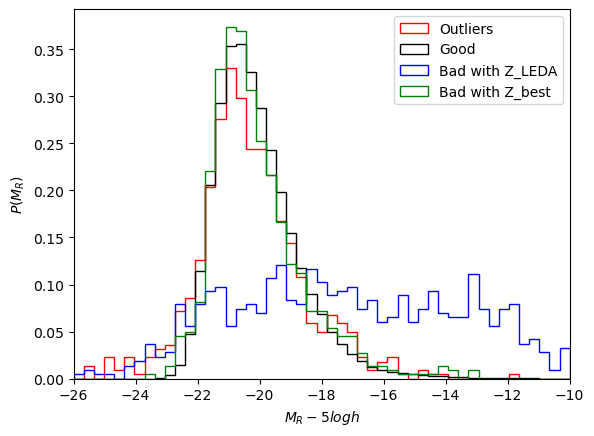

In [11]:
# Compare Absolute magnitudes of the Good and Bad objects

# For All the objects in SGA that have redshifts flag as bad those that disagree with the DESI redshift
augbad = (np.abs(sga['Z_LEDA']-aug['Z'][indx_aug[idx_tar]]) >0.01) & (sga['Z_LEDA']>0) 
# For just those that match with the DESI full catalogue flag them as good or bad redshift
augmatchedgood= matched_aug[idx_tar] & ~augbad
augmatchedbad= matched_aug[idx_tar] & augbad
#Fraction of Matched objects that have discrepant redshifts
fracbad= f"{100.0*augmatchedbad.sum()/matched_aug.sum():.4f}"

# Scatter plot of DESI Z versus Z_LEDA with good and bad flagged
plt.scatter(sga['Z_LEDA'][augmatchedbad],aug['Z'][indx_aug[idx_tar]][augmatchedbad],color='red',s=0.5,marker='.',linewidths=1,label='Outliers:'+fracbad+"%")
plt.scatter(sga['Z_LEDA'][augmatchedgood],aug['Z'][indx_aug[idx_tar]][augmatchedgood],color='black',s=0.5,marker='.',linewidths=1,label='Good')
plt.xlim([0,0.6])
plt.ylim([0.0,0.6])
plt.xlabel('$z_{LEDA}$')
plt.ylabel('$z_{DESI}$')
plt.legend()
plt.show()

#Define a "fixed" absolute magnitude for the outliers using the Z_LEDA in place of the DESI z (doesn't account for changed k-correction)
Qevol=0.78
ABSMAG_RP1=aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad] + 5.0*np.log10(ca.cosmo.luminosity_distance(aug['Z'][indx_aug[idx_tar]][augmatchedbad])/ca.cosmo.luminosity_distance(sga['Z_LEDA'][augmatchedbad])) 
-Qevol*(aug['Z'][indx_aug[idx_tar]][augmatchedbad]-sga['Z_LEDA'][augmatchedbad])

# Scatter of Absolute magnitude versus Z_LEDA
plt.scatter(sga['Z_LEDA'][augmatchedbad],aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad],color='red',s=0.5,marker='.',linewidths=1,label='Outliers:'+fracbad+"%")
plt.scatter(sga['Z_LEDA'][augmatchedgood],aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedgood],color='black',s=0.5,marker='.',linewidths=1,label='Good')
plt.scatter(sga['Z_LEDA'][augmatchedbad],ABSMAG_RP1,color='blue',s=2.5,marker='.',linewidths=1,label='Outliers:'+fracbad+"%")
plt.scatter(zbest,ABSMAG_RP1_best,color='green',s=2.5,marker='.',linewidths=1,label='Fixed')
plt.xlim([0,0.6])
plt.ylim([-26,-10])
plt.xlabel('$z_{LEDA}$')
plt.ylabel('$M_R-5 log h$')
plt.legend()
plt.show()

# Scatter plot of Magnitude using Z_LEDA to the orginal DESI Magnitude
plt.scatter(ABSMAG_RP1,aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad],color='blue',s=2.5,marker='.',linewidths=1,label='Outliers:'+fracbad+"%")
plt.xlim([-26,-10])
plt.ylim([-26,-10])
plt.xlabel('$M_R-5 log h$ Z_LEDA')
plt.ylabel('$M_R-5 log h$ DESI Z')
plt.legend()
plt.show()

# Histogram of the Outlier DESI z 
plt.hist(aug['Z'][indx_aug[idx_tar]][augmatchedbad],bins=100,color='black',density=True, alpha=1.0,histtype='step',label='Outliers')
plt.xlim([0,0.6])
plt.ylabel('$P(z)$')
plt.xlabel('$z$')
plt.legend()
plt.show()

# Histograms of the Absolute Magnitude distributions of Good, Outlier and "Fixed Outlier" samples
bins=np.linspace(-26,-10,50)
plt.hist(aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad], bins=bins, color='red', label='Outliers', histtype='step', density=True ,alpha=1.0)
plt.hist(aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedgood], bins=bins, color='black', label='Good', histtype='step',  density=True, alpha=1.0)
plt.hist(ABSMAG_RP1, bins=bins, color='blue', label='Bad with Z_LEDA', density=True, alpha=1.0,histtype='step')

# Store the histogram for the Good sample and use it as an indication of the expected probability of having a given magnitude
prob, bin_edges = np.histogram(aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedgood], bins=bins, density=True)
# For the outlier sample calculate for both Z_LEDA and DESI z the probability of the corresponding magnitude 
# and store the magnitude and redshift of the most probable
idx_DESI = np.searchsorted(bin_edges, aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad], side='right') - 1
idx_LEDA = np.searchsorted(bin_edges, ABSMAG_RP1, side='right') - 1
# Values outside the range get zero density
out_of_range_DESI = (idx_DESI < 0) | (idx_DESI >= len(prob))
out_of_range_LEDA = (idx_LEDA < 0) | (idx_LEDA >= len(prob))
prob_LEDA= np.zeros_like(ABSMAG_RP1, dtype=float)
prob_LEDA[~out_of_range_LEDA] = prob[idx_LEDA[~out_of_range_LEDA]]
prob_DESI= np.zeros_like(ABSMAG_RP1, dtype=float)
prob_DESI[~out_of_range_DESI] = prob[idx_DESI[~out_of_range_DESI]]
# By default pick the DESI redshift
zbest = aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad]
ABSMAG_RP1_best = aug['ABSMAG_RP1'][indx_aug[idx_tar]][augmatchedbad]
#But overwrite if Z_LEDA more probable
mask = (prob_LEDA>prob_DESI)
zbest[mask] =sga['Z_LEDA'][augmatchedbad][mask]
ABSMAG_RP1_best[mask]=ABSMAG_RP1[mask]

plt.hist(ABSMAG_RP1_best, bins=bins, color='green', label='Bad with Z_best', density=True, alpha=1.0,histtype='step')
plt.xlim([-26,-10])
plt.ylabel('$P(M_R)$')
plt.xlabel('$M_R-5 log h$')
plt.legend()
plt.show()

In [12]:
# Store a small catalogue of SGA objects for which the Z_LEDA redshift is better than the DESI redshift
sgabetter= Table()
sgabetter['Z_LEDA']=sga['Z_LEDA'][augmatchedbad][mask]
sgabetter['RA_LEDA']=sga['RA_LEDA'][augmatchedbad][mask]
sgabetter['DEC_LEDA']=sga['DEC_LEDA'][augmatchedbad][mask]
sgabetter['TARGETID']=target['TARGETID'][idx_tar][augmatchedbad][mask]


sgabetter.write('sdata/SGAbetter.fits',overwrite=True) 
sgabetter.info('stats')

<Table length=147>
  name       mean        std         min         max    
-------- ----------- ----------- ----------- -----------
  Z_LEDA   0.0776161   0.0668794  0.00189798    0.477167
 RA_LEDA     178.349     82.0242     2.19314     358.863
DEC_LEDA     15.1052     23.8627    -16.2975     72.9481
TARGETID 3.96292e+16 2.39482e+12 3.96274e+16 3.96368e+16


In [18]:
# Sort the table by Magnitude in descending order
sgabetter.sort('Z_LEDA')



# Print all information for these rows
cols= [ 'TARGETID', 'RA_LEDA', 'DEC_LEDA', 'Z_LEDA' ]
print(sgabetter[cols])

mask = (sgabetter['TARGETID']==39633286472928387) | (sgabetter['TARGETID']==39627956712114667)
print(sgabetter[cols][mask])

     TARGETID          RA_LEDA             DEC_LEDA         Z_LEDA   
----------------- ------------------ ------------------- ------------
39633212191802937        180.1474395          47.7739525 0.0018979796
39633251983164574        182.8449075           50.269664 0.0026041348
39633263488139339          179.60664          50.9170314  0.003056114
39633445613210946         168.059349   65.22545749999999 0.0035571274
39627815217268316         17.2918095           1.2911919  0.003649191
39628342743273687         337.028139          23.3762991  0.004262949
39633048374870821        150.7583115          38.3771622   0.00446709
39627944708016011  189.6524743942448   6.503429644699405 0.0049214046
39633493809956279          182.59215           70.515404  0.007084901
39633255212781420 123.61241550000001           50.576807  0.007832752
              ...                ...                 ...          ...
39627709680194355   206.752627144173  -3.329085324773521   0.17740606
39628051406914950 13

In [ ]:
39633286472928387